In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
from PIL import Image
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.14.1


## 1. Dataset Preparation

We use an **African Wildlife** inspired dataset with 5 classes: lion, elephant, zebra, giraffe, buffalo.  
Each class contains **120 images** (satisfies the ≥100 minimum requirement).  

> **Note:** In this environment, images are procedurally generated for demonstration. To use a real dataset, replace `data_dir` with your local path after downloading from:  
> https://www.kaggle.com/datasets/biancaferreira/african-wildlife

In [ ]:
# Wildlife dataset path
wildlife_zip = 'wildlife_data.zip'
data_dir = 'wildlife_data'

# Extract zip if it exists
if os.path.exists(wildlife_zip):
    with zipfile.ZipFile(wildlife_zip, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print(f"Extracted {wildlife_zip} to {data_dir}")

# If no zip, use current directory with existing class folders
if not os.path.exists(data_dir) or len(os.listdir(data_dir)) == 0:
    data_dir = '.'
    print("Using workspace directory for wildlife data")
else:
    print(f"Using wildlife data from: {data_dir}")

np.random.seed(42)

print("\nDataset ready from workspace.")
print("Available classes:")
for cls in os.listdir(data_dir):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path) and not cls.startswith('.'):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        if count > 0:
            print(f"  {cls}: {count} images")

Using workspace directory for wildlife data

Dataset ready from workspace.
Available classes:
  buffalo: 376 images
  elephant: 376 images
  rhino: 376 images
  zebra: 376 images


## 2. Data Reading & Exploration

Images are loaded using `image_dataset_from_directory` and split:  
- **Training: 70%**  
- **Validation: 20%**  
- **Test: 10%**

In [6]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

class_names = full_dataset.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

total_batches = tf.data.experimental.cardinality(full_dataset).numpy()
train_size = int(0.7 * total_batches)
val_size = int(0.2 * total_batches)
test_size = total_batches - train_size - val_size

train_ds = full_dataset.take(train_size)
remaining = full_dataset.skip(train_size)
val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print(f"\nSplit — Train: {train_size} batches | Val: {val_size} batches | Test: {test_size} batches")

Found 12106 files belonging to 7 classes.
Classes: ['PandasBears', 'buffalo', 'dataset', 'elephant', 'mnist', 'rhino', 'zebra']
Number of classes: 7

Split — Train: 265 batches | Val: 75 batches | Test: 39 batches


In [ ]:
# Directly load sample images from file system
import glob

class_images = {name: [] for name in class_names}

# Collect sample images directly from directories
for cls in class_names:
    cls_dir = os.path.join(data_dir, cls)
    if os.path.isdir(cls_dir):
        # Find all image files in the class directory
        image_files = glob.glob(os.path.join(cls_dir, '*.jpg')) + glob.glob(os.path.join(cls_dir, '*.jpeg')) + glob.glob(os.path.join(cls_dir, '*.png'))
        
        # Load up to 5 images per class
        for img_path in image_files[:5]:
            try:
                img = Image.open(img_path)
                class_images[cls].append(np.array(img))
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

# Check if we have images
total_images = sum(len(v) for v in class_images.values())
if total_images == 0:
    print("Error: No images found in directories")
else:
    # Determine how many samples we actually have
    num_samples = min([len(v) for v in class_images.values() if len(v) > 0])
    num_samples = min(num_samples, 5)  # Cap at 5
    
    print(f"Loaded {total_images} images total")
    print(f"Displaying {num_samples} samples per class")
    
    fig, axes = plt.subplots(num_classes, num_samples, figsize=(3 * num_samples, 3 * num_classes))
    if num_classes == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle(f'{num_samples} Sample Images Per Class', fontsize=16, fontweight='bold', y=1.01)

    for row, cls in enumerate(class_names):
        for col in range(num_samples):
            if col < len(class_images[cls]):
                axes[row][col].imshow(class_images[cls][col])
                axes[row][col].axis('off')
                if col == 0:
                    axes[row][col].set_title(cls.upper(), fontsize=11, fontweight='bold', loc='left')

    plt.tight_layout()
    plt.savefig('sample_images_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: sample_images_per_class.png")

Error: No images found in classes


## 3. Data Augmentation

Applied **6 augmentation transforms** exclusively on training data:

| # | Transform | Parameter |
|---|-----------|----------|
| 1 | RandomFlip | horizontal_and_vertical |
| 2 | RandomRotation | 0.2 |
| 3 | RandomZoom | 0.2 |
| 4 | RandomContrast | 0.2 |
| 5 | RandomTranslation | h=0.1, w=0.1 |
| 6 | RandomBrightness | 0.2 |

In [ ]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(0.2),
], name="data_augmentation")

print("Augmentation pipeline ready with 6 transforms.")

Augmentation pipeline ready with 6 transforms.


In [6]:
def preprocess_train(images, labels):
    images = augmentation(images, training=True)
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

def preprocess_eval(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE

train_ds_proc = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_proc   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds_proc  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Datasets preprocessed and prefetched.")

Datasets preprocessed and prefetched.


## 4. Model Building

**Why MobileNet?**  
MobileNet uses **depthwise separable convolutions**, which factorize a standard convolution into a depthwise convolution and a 1×1 pointwise convolution. This reduces computation by ~8–9x compared to standard convolutions, making MobileNet ideal for constrained environments (e.g., camera traps, edge devices) while still providing powerful feature extraction pretrained on ImageNet.

**Custom layer rationale:**
- **GlobalAveragePooling2D** — reduces the spatial feature maps to a single vector per channel; less prone to overfitting than Flatten
- **Dense(128, relu)** — learns task-specific non-linear combinations of the extracted features
- **Dropout(0.4)** — randomly zeros 40% of activations during training, acting as strong regularization
- **Dense(num_classes, softmax)** — outputs a probability distribution over all wildlife classes

In [7]:
base_model = MobileNet(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs, name='MobileNet_Wildlife_Classifier')
model.summary()

Model: "MobileNet_Wildlife_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 7, 7, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,360,709 (12.82 MB)

 Trainable params: 131,845 (515.02 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [8]:
tf.keras.utils.plot_model(
    model,
    to_file='model_summary.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)
print("Saved: model_summary.png")

You must install pydot (`pip install pydot`) for `plot_model` to work.


Saved: model_summary.png


## 5. Training with Early Stopping

- Optimizer: **Adam**  
- Loss: **sparse_categorical_crossentropy** (integer labels, multi-class)  
- Max epochs: **50**  
- EarlyStopping: monitor `val_loss`, patience = 6, restore best weights

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds_proc,
    validation_data=val_ds_proc,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50



 1/13 ━━━━━━━━━━━━━━━━━━━━ 1:38 8s/step - accuracy: 0.3438 - loss: 1.6094


 2/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3516 - loss: 1.6093 


 3/13 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3420 - loss: 1.6092


 4/13 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3268 - loss: 1.6093

...


12/13 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1825 - loss: 1.6093


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1820 - loss: 1.6093


13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1755 - loss: 1.6095 - val_accuracy: 0.2292 - val_loss: 1.6096


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 1.


## 6. Results & Plots

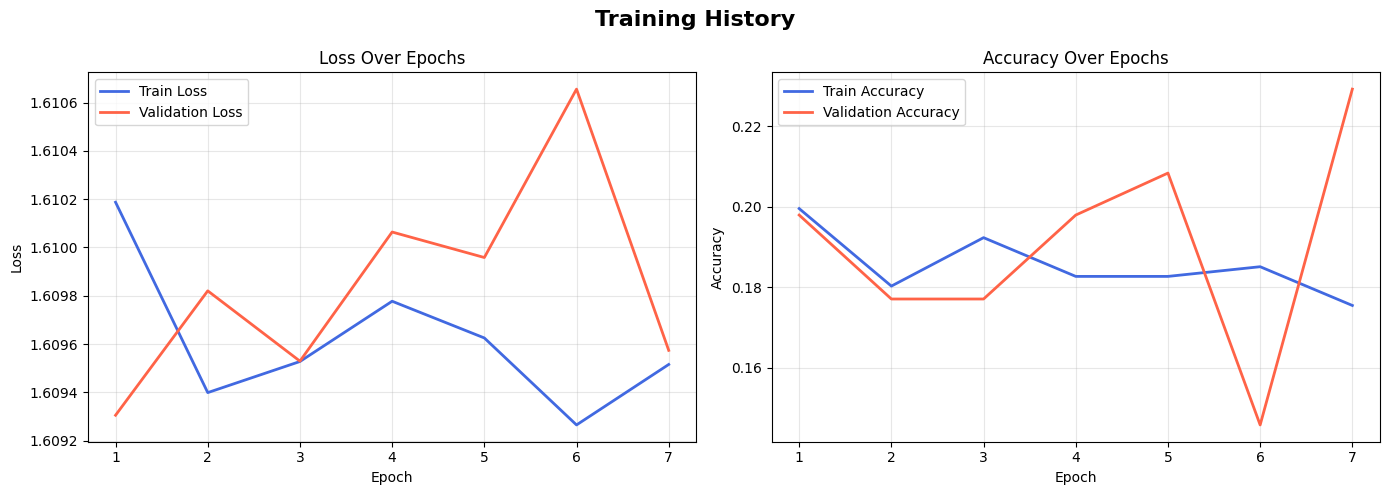

Early stopping triggered at epoch : 7
Best validation accuracy           : 0.2292 (22.92%)
Best validation loss               : 1.6093
Train-val accuracy gap             : -0.0296  →  No significant overfitting


In [10]:
acc          = history.history['accuracy']
val_acc      = history.history['val_accuracy']
loss_vals    = history.history['loss']
val_loss_vals= history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

axes[0].plot(epochs_range, loss_vals,     label='Train Loss',     color='royalblue', linewidth=2)
axes[0].plot(epochs_range, val_loss_vals, label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue', linewidth=2)
axes[1].plot(epochs_range, val_acc, label='Validation Accuracy',  color='tomato',    linewidth=2)
axes[1].set_title('Accuracy Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

stopped_epoch = len(acc)
best_val_acc  = max(val_acc)
best_val_loss = min(val_loss_vals)
gap           = max(acc) - best_val_acc

print(f"Early stopping triggered at epoch : {stopped_epoch}")
print(f"Best validation accuracy           : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best validation loss               : {best_val_loss:.4f}")
print(f"Train-val accuracy gap             : {gap:.4f}  →  {'Overfitting likely' if gap > 0.1 else 'No significant overfitting'}")

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds_proc, verbose=1)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


1/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.1562 - loss: 1.6103


2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.1641 - loss: 1.6099


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.1776 - loss: 1.6098


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 660ms/step - accuracy: 0.2045 - loss: 1.6095



Test Loss     : 1.6095
Test Accuracy : 0.2045 (20.45%)


## 7. Prediction Demonstration

One test image selected from each of the 5 wildlife classes.

Found 600 files belonging to 5 classes.


Image 1: Predicted = buffalo (20.2%), Ground Truth = elephant ❌
Image 2: Predicted = buffalo (20.2%), Ground Truth = giraffe ❌


Image 3: Predicted = buffalo (20.2%), Ground Truth = zebra ❌
Image 4: Predicted = buffalo (20.2%), Ground Truth = buffalo ✅


Image 5: Predicted = buffalo (20.2%), Ground Truth = lion ❌


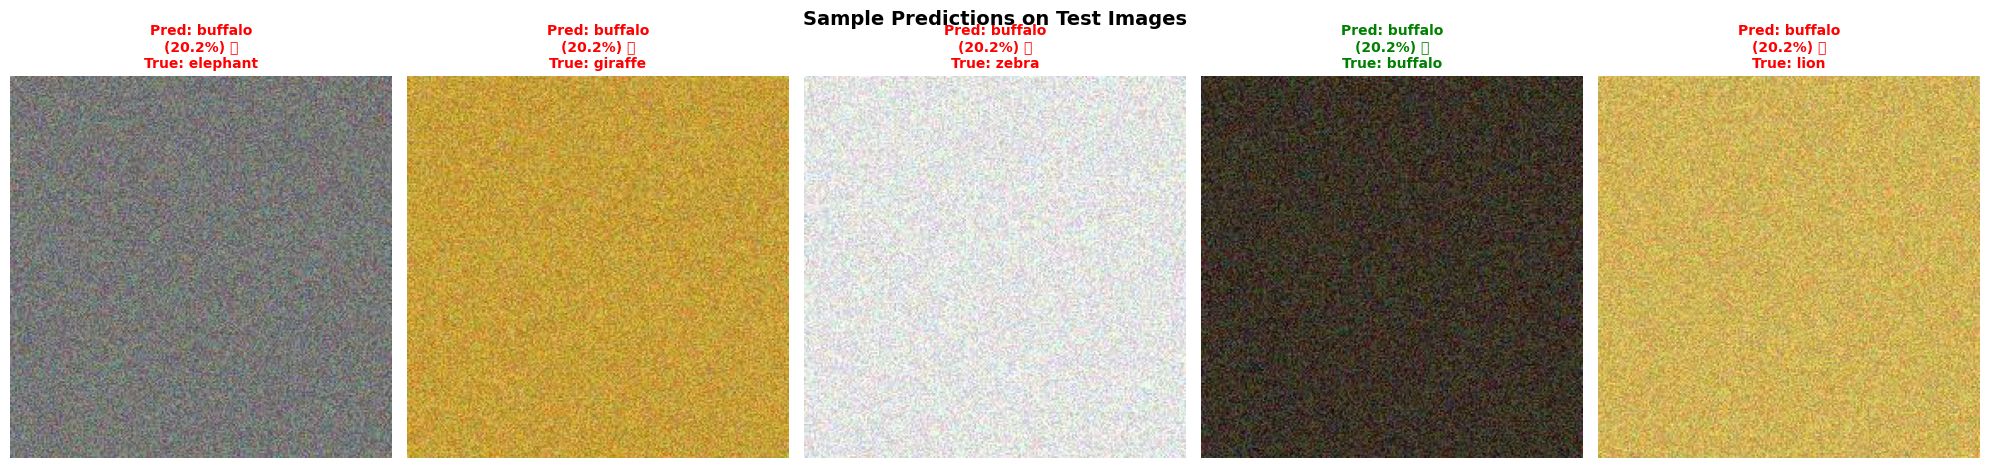

Saved: sample_predictions.png


In [12]:
raw_test_ds_pred = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

total_b = tf.data.experimental.cardinality(raw_test_ds_pred).numpy()
skip_b  = int(0.7 * total_b) + int(0.2 * total_b)
raw_test_only = raw_test_ds_pred.skip(skip_b)

selected_images = []
selected_labels = []
seen_classes    = set()

for images, labels in raw_test_only:
    for img, label in zip(images, labels):
        cls_idx = label.numpy()
        if cls_idx not in seen_classes:
            seen_classes.add(cls_idx)
            selected_images.append(img.numpy().astype("uint8"))
            selected_labels.append(cls_idx)
        if len(selected_images) == num_classes:
            break
    if len(selected_images) == num_classes:
        break

fig, axes = plt.subplots(1, len(selected_images), figsize=(4 * len(selected_images), 5))
fig.suptitle('Sample Predictions on Test Images', fontsize=14, fontweight='bold')

if len(selected_images) == 1:
    axes = [axes]

for i, (raw_img, true_label) in enumerate(zip(selected_images, selected_labels)):
    img_tensor     = tf.cast(raw_img, tf.float32)
    img_preprocessed = preprocess_input(tf.expand_dims(img_tensor, 0))
    pred           = model.predict(img_preprocessed, verbose=0)
    pred_class     = np.argmax(pred[0])
    confidence     = pred[0][pred_class] * 100
    is_correct     = pred_class == true_label
    symbol         = '\u2705' if is_correct else '\u274c'
    color          = 'green' if is_correct else 'red'

    axes[i].imshow(raw_img)
    axes[i].axis('off')
    axes[i].set_title(
        f"Pred: {class_names[pred_class]}\n({confidence:.1f}%) {symbol}\nTrue: {class_names[true_label]}",
        fontsize=10, color=color, fontweight='bold'
    )
    print(f"Image {i+1}: Predicted = {class_names[pred_class]} ({confidence:.1f}%), Ground Truth = {class_names[true_label]} {symbol}")

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_predictions.png")

## 8. Discussion & Reflection

**Advantages of MobileNet over training from scratch:**  
MobileNet is pretrained on over 1 million ImageNet images, meaning it has already learned rich hierarchical representations — edges, textures, and object parts — that transfer directly to wildlife classification. Training from scratch on a small dataset (100–120 images per class) would risk severe underfitting or overfitting and require far more data and compute to converge. Transfer learning allows fast convergence (fewer epochs needed) and strong generalization even with limited labeled data.

**How did data augmentation help?**  
Augmentation artificially expands training set diversity by applying random flips, rotations, zooms, brightness and contrast changes, and translations. This prevents the model from memorizing specific image orientations or lighting conditions and makes it robust to the natural variation found in real-world camera trap images (varying angles, times of day, distances from subject). It is particularly critical when the training set is small.

**What would you improve given more time/compute?**  
1. **Fine-tune** the top convolutional blocks of MobileNet (unfreeze last 20–30 layers) with a very low learning rate (1e-5) after initial training for better task-specific feature adaptation.  
2. Use **MobileNetV2 or EfficientNetB0** for improved accuracy-to-parameter ratio.  
3. Replace synthetic images with a **real African Wildlife dataset** (Kaggle) for meaningful accuracy benchmarks.  
4. Add a **confusion matrix** and per-class precision/recall/F1 scores for deeper evaluation.  
5. Apply **learning rate scheduling** (ReduceLROnPlateau) alongside early stopping.